<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_01/Hw2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашня робота

In [1]:
import pandas as pd
import numpy as np

Прочитайте дані за допомогою методу read_html з таблиці "Коефіцієнт народжуваності в регіонах України (1950—2019)" посилання

In [2]:
url = "https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8"
match_str = "Коефіцієнт народжуваності в регіонах України"
table = pd.read_html(url, match=match_str, decimal=',', thousands='.')
df = table[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Вивести перші рядки таблиці за допомогою методу head

In [3]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—


Визначте кількість рядків та стовпців у датафреймі (атрибут shape)

In [4]:
df.shape

(28, 9)

Замініть у таблиці значення "—" на значення NaN

In [5]:
df.replace('—', np.nan, inplace=True)
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [6]:
df.dtypes

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014       object
2019       object
dtype: object

Замініть типи нечислових колонок на числові. Підказка - це колонки, де знаходився символ "—"

In [7]:
to_convert = df.columns[1:]
df[to_convert] = df[to_convert].apply(pd.to_numeric, errors='coerce')
df.dtypes

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object

Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)

In [8]:
missing_proportion = (df.isnull().sum() / len(df)).round(4)
missing_proportion

Регіон    0.0000
1950      0.0714
1960      0.0357
1970      0.0357
1990      0.0000
2000      0.0000
2012      0.0000
2014      0.0714
2019      0.1429
dtype: float64

Видаліть з таблиці дані по всій країні, останній рядок таблиці

In [9]:
df = df.iloc[:-1]
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Замініть відсутні дані в стовпцях середніми значеннями цих стовпців (метод fillna)

In [10]:
columns_to_fill = df.columns[1:]
df.loc[:, columns_to_fill] = df.loc[:, columns_to_fill].fillna(df[columns_to_fill].mean())
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.000,20.600000,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.400,19.200000,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.700,25.000000,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.400,20.400000,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.100,21.400000,14.0,10.9,6.1,9.8,8.200,8.017391
5,Житомирська,26.100,22.300000,15.9,12.9,8.9,12.2,12.000,7.900000
6,Закарпатська,31.400,27.300000,20.7,16.8,11.5,15.1,14.600,10.400000
7,Запорізька,21.900,19.700000,15.0,12.4,7.1,10.6,10.600,6.800000
8,Івано-Франківська,24.300,24.800000,18.2,15.5,10.3,12.4,12.200,8.800000
9,Київська,20.400,18.900000,15.6,12.3,7.3,12.2,12.100,8.000000


Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні

In [11]:
df_search = df[['Регіон', '2019']]
filtered = df_search[df_search['2019'] > df_search['2019'].mean()]
region_list = filtered['Регіон'].tolist()
region_list

['Волинська',
 'Закарпатська',
 'Івано-Франківська',
 'Львівська',
 'Одеська',
 'Рівненська',
 'Херсонська',
 'Чернівецька',
 'Київ']

У якому регіоні була найвища народжуваність у 2014 році?

In [12]:
max_region = df.loc[df['2014'].idxmax(), 'Регіон']
max_region

'Рівненська'

Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році

In [13]:
%matplotlib inline

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

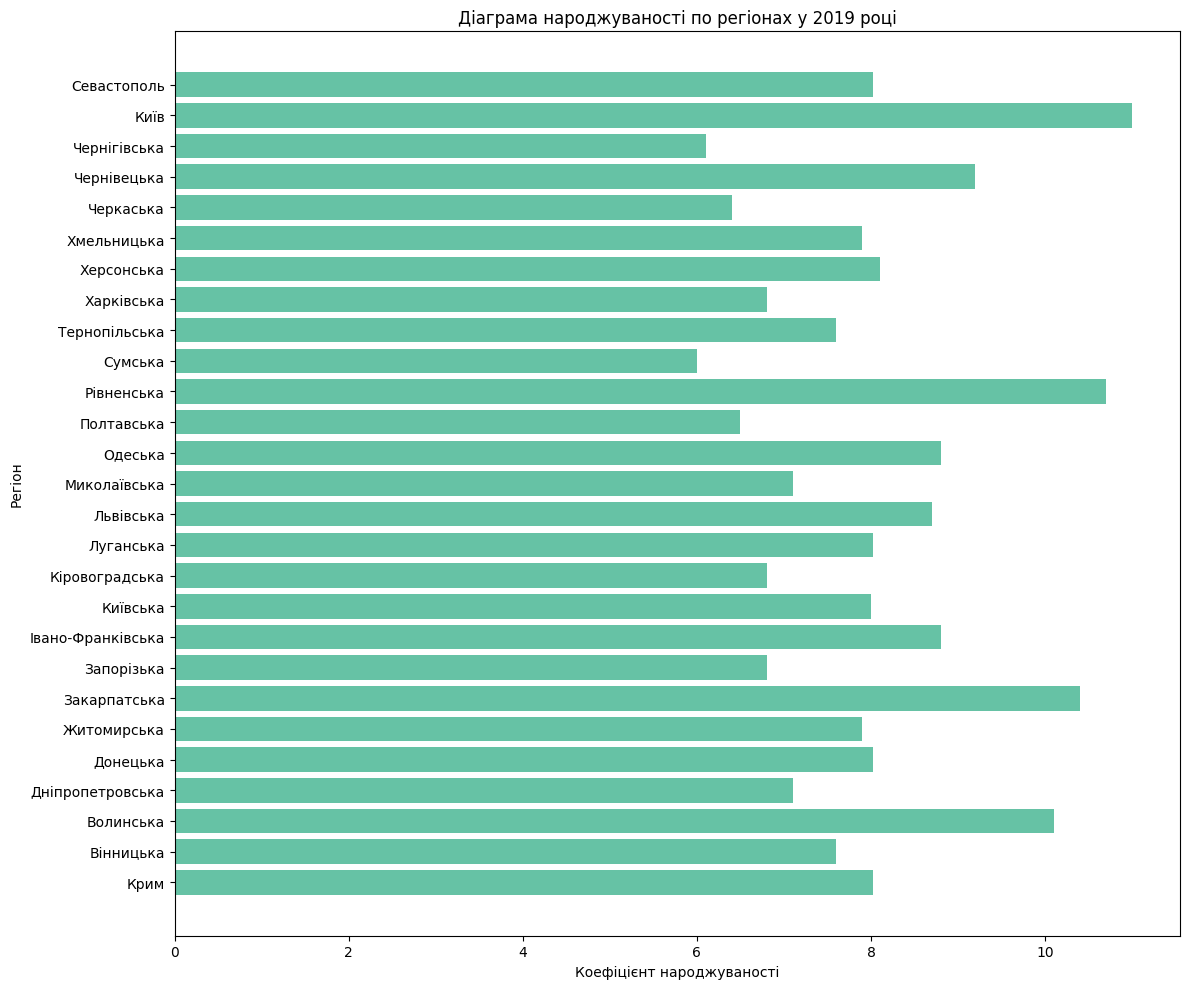

In [15]:
palette = sns.color_palette("Set2", n_colors=2)

plt.figure(figsize=(12, 10))
plt.barh(df['Регіон'], df['2019'], color=palette[0])
plt.title('Діаграма народжуваності по регіонах у 2019 році')
plt.ylabel('Регіон')
plt.xlabel('Коефіцієнт народжуваності')
plt.tight_layout()

plt.show()

# Графіки

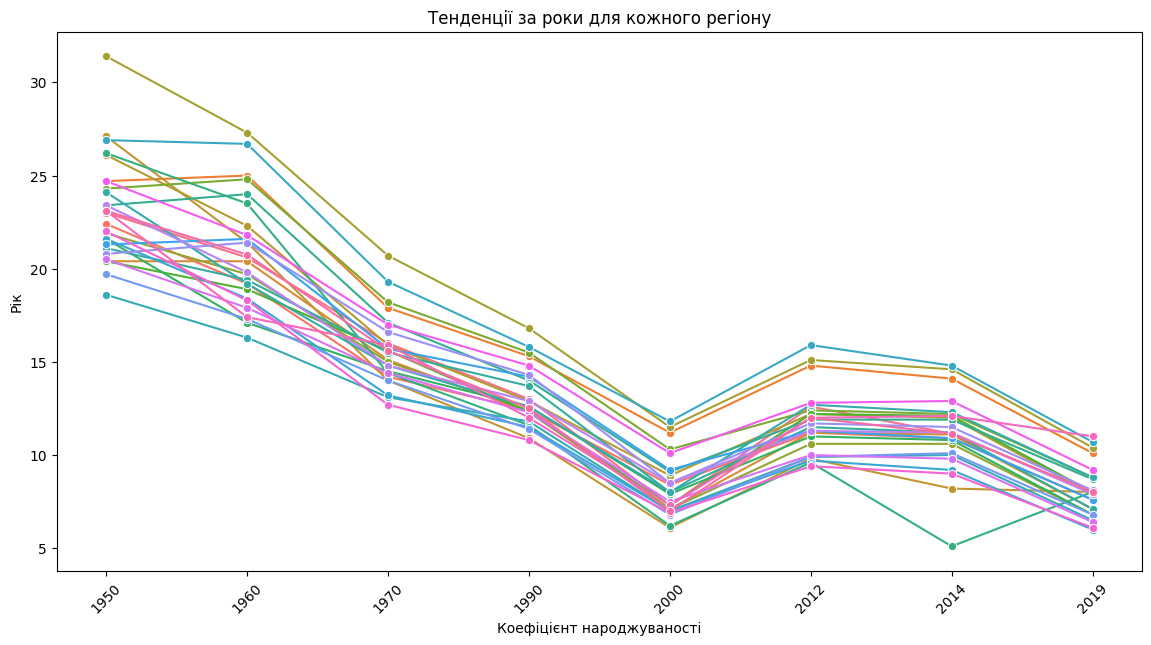

In [16]:
# @title Тенденції за роки для кожного регіону

# Melt the dataframe to long format
df_melt = df.melt(id_vars='Регіон', var_name='Year', value_name='Value')

# Line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_melt, x='Year', y='Value', hue='Регіон', marker='o', legend=False)
plt.title('Тенденції за роки для кожного регіону')
plt.xticks(rotation=45)
plt.ylabel('Рік')
plt.xlabel('Коефіцієнт народжуваності')
plt.legend
plt.show()

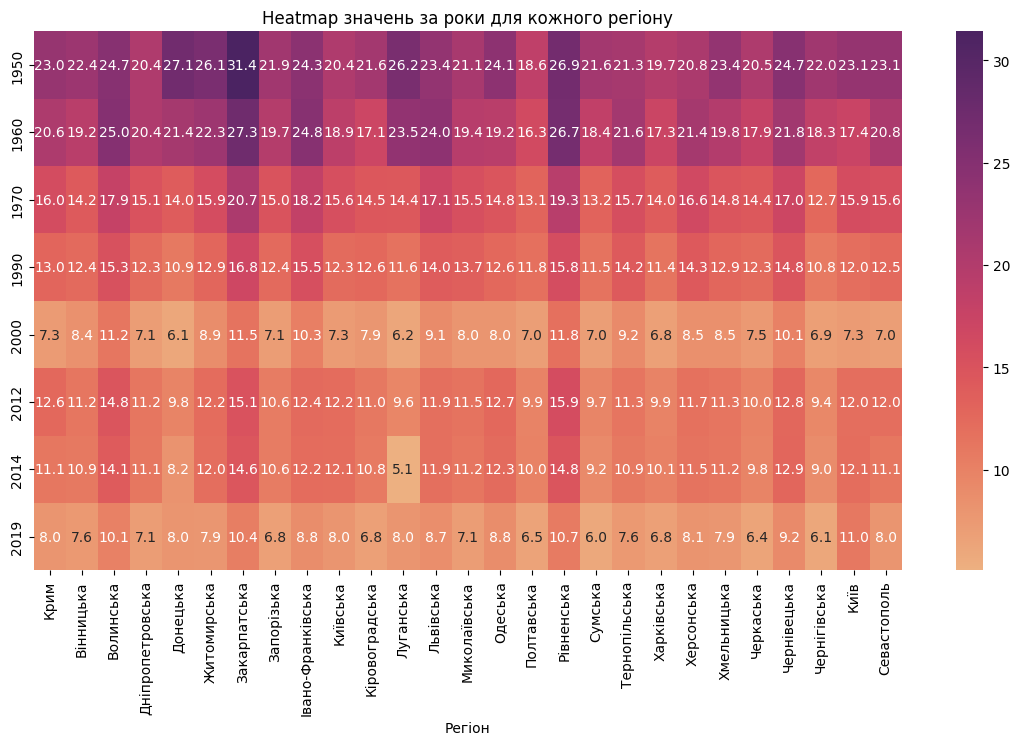

In [17]:
# @title Тенденції за роки для кожного регіону
plt.figure(figsize=(14, 7))
sns.heatmap(df.set_index('Регіон').T, cmap='flare', annot=True, fmt='.1f')
plt.title('Heatmap значень за роки для кожного регіону')
plt.show()


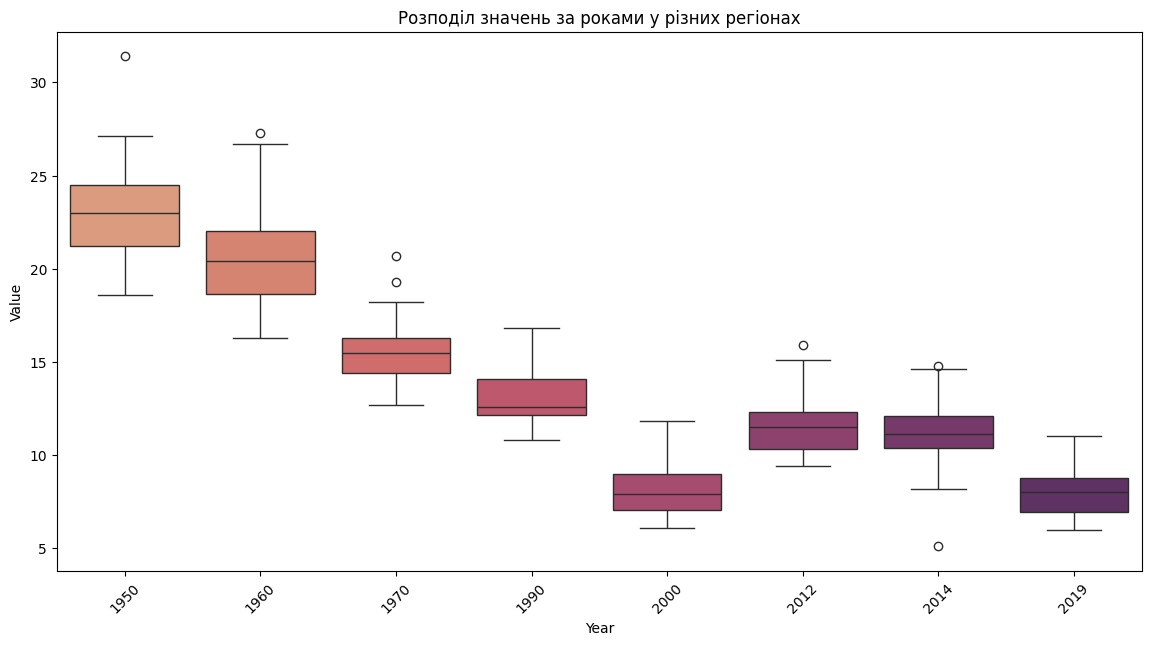

In [25]:
# @title Розподіл значень за роками у різних регіонах

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_melt, x='Year', y='Value', hue='Year', palette='flare', dodge=False)
plt.title('Розподіл значень за роками у різних регіонах')
plt.xticks(rotation=45)
plt.legend([],[], frameon=False)
plt.show()